In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
## opens sqlite database

conn = sqlite3.connect("../backend/data/game.db")

def statement_to_df(s: str):
    cursor = conn.cursor()
    cursor.execute(s)
    conn.commit()
    cols = [description[0] for description in cursor.description]
    list = cursor.fetchall()
    df = pd.DataFrame(list, columns=cols)
    return df

def get_tables():
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    return [table[0] for table in tables]

    

def plot_statement(s: str):
    df = statement_to_df(s)
    ## now plot
    plt.plot(df)
    plt.show()

In [31]:
get_tables()

['kills', 'players', 'servers', 'sqlite_sequence', 'server_ticks', 'pings']

In [36]:
statement_to_df("select * from server_ticks where game_id = 9").head()

,id,game_id,tick,micros_elapsed
0,282883,9,0,23
1,282885,9,1,0
2,282887,9,2,0
3,282889,9,3,0
4,282891,9,4,0


<Axes: xlabel='x'>

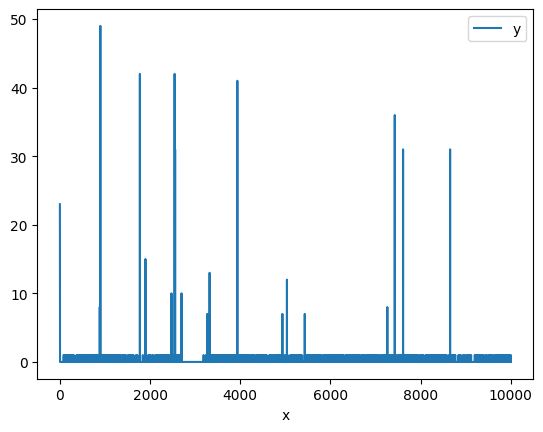

In [43]:
statement_to_df("select tick as x, micros_elapsed as y from server_ticks where game_id = 9 limit 10000").plot(x='x', y='y')

In [45]:
statement_to_df("select * from pings limit 10")

,id,player_id,micros
0,1,22,189220
1,2,22,189218
2,3,22,189217
3,4,22,189216
4,5,22,189214
5,6,22,189213
6,7,22,189212
7,8,22,189211
8,9,22,180140
9,10,22,177886


,x,y
count,10000.00000,10000.000000
mean,5000.50000,167689.481600
std,2886.89568,9557.987732
min,1.00000,142852.000000
25%,2500.75000,160899.500000
50%,5000.50000,166614.000000
75%,7500.25000,174716.750000
max,10000.00000,229345.000000


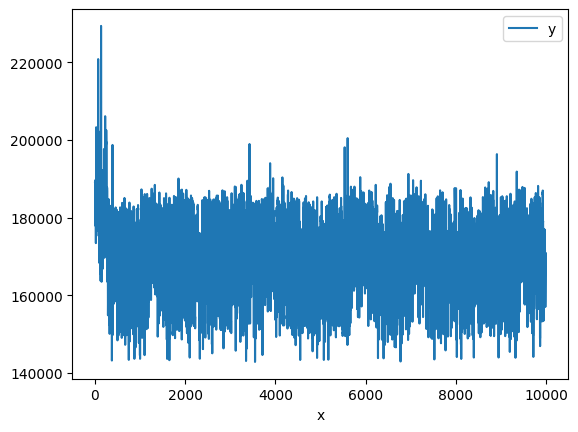

In [50]:
df = statement_to_df("select id as x, micros as y from pings limit 10000")
df.plot(x='x', y='y')
df.describe()